# Análisis Exploratorio de Datos: EcoBici CDMX

El sistema **EcoBici** es una de las fuentes de datos abiertos más ricas de la Ciudad de México. A diferencia de otros datasets estáticos, este nos permite analizar la **dinámica urbana** a través del tiempo y el espacio.

## Objetivos del Notebook
1. **Procesamiento de Fechas**: Aprender a manejar formatos `datetime`.
2. **Limpieza de Outliers**: Identificar viajes inválidos o técnicos.
3. **Patrones Temporales**: ¿A qué hora se usa más el sistema? ¿Cómo cambia el fin de semana?
4. **Análisis de Origen-Destino**: Identificar las estaciones con mayor demanda.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Carga de Datos

Utilizaremos un archivo mensual de los datos abiertos de la CDMX. 
> **Nota**: Estos archivos suelen ser grandes (>100MB). Para este ejercicio, puedes descargar uno directamente de: [Datos Abiertos CDMX](https://ecobici.cdmx.gob.mx/datos-abiertos/?gad_source=1&gad_campaignid=23606083357&gbraid=0AAAAA_xfLRMWRYYEEcXy4H5OkTwa61_bX&gclid=CjwKCAiAzZ_NBhAEEiwAMtqKy0W0-5T-8bSJuHWIbLFwQc_-JzKeAB3_ITlPlGvu2Hii05-1Ymb5uRoC0MEQAvD_BwE)

In [46]:
# URL de ejemplo (Enero 2026)
df = pd.read_csv(
    "https://ecobici.cdmx.gob.mx/wp-content/uploads/2026/02/2026-01.csv",
    low_memory=True
)

#df = pd.read_csv(
#    "~/Downloads/2026-01.csv",
#    low_memory=True
#)

In [47]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 1525302 entries, 0 to 1525301
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Genero_Usuario         1525301 non-null  str    
 1   Edad_Usuario           1525223 non-null  float64
 2   Bici                   1525302 non-null  int64  
 3   Ciclo_Estacion_Retiro  1525302 non-null  str    
 4   Fecha_Retiro           1525302 non-null  str    
 5   Hora_Retiro            1525302 non-null  str    
 6   Ciclo_EstacionArribo   1525302 non-null  str    
 7   Fecha_Arribo           1525302 non-null  str    
 8   Hora_Arribo            1525302 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 585.2 MB


In [48]:
df

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo
0,M,30.0,4933404,059,31/12/2025,23:25:20,565,01/01/2026,00:00:16
1,M,27.0,4162376,180,31/12/2025,23:43:53,672,01/01/2026,00:00:31
2,M,29.0,3749272,014,31/12/2025,23:52:15,030,01/01/2026,00:00:50
3,M,44.0,5680772,014,31/12/2025,23:46:43,145,01/01/2026,00:00:53
4,M,22.0,5128459,031,31/12/2025,23:39:58,155,01/01/2026,00:01:05
...,...,...,...,...,...,...,...,...,...
1525297,M,35.0,3731882,083,31/01/2026,23:52:13,258,31/01/2026,23:59:13
1525298,M,37.0,2684900,279,31/01/2026,23:44:43,589,31/01/2026,23:59:40
1525299,M,36.0,2286797,320,31/01/2026,23:54:49,340,31/01/2026,23:59:50
1525300,M,28.0,5117957,074,31/01/2026,23:54:02,038,31/01/2026,23:59:51


In [49]:
df_clean = (
    df
    .assign(
        inicio = lambda x: pd.to_datetime(x.Fecha_Retiro + " " + x.Hora_Retiro, dayfirst=True),
        fin = lambda x: pd.to_datetime(x.Fecha_Arribo + " " + x.Hora_Arribo, dayfirst=True)
    )
    .assign(
        duracion_viaje = lambda x: x.fin - x.inicio,
        dia_semana = lambda x: x.inicio.dt.day_name()
    )
)

In [50]:
df_clean

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,inicio,fin,duracion_viaje,dia_semana
0,M,30.0,4933404,059,31/12/2025,23:25:20,565,01/01/2026,00:00:16,2025-12-31 23:25:20,2026-01-01 00:00:16,0 days 00:34:56,Wednesday
1,M,27.0,4162376,180,31/12/2025,23:43:53,672,01/01/2026,00:00:31,2025-12-31 23:43:53,2026-01-01 00:00:31,0 days 00:16:38,Wednesday
2,M,29.0,3749272,014,31/12/2025,23:52:15,030,01/01/2026,00:00:50,2025-12-31 23:52:15,2026-01-01 00:00:50,0 days 00:08:35,Wednesday
3,M,44.0,5680772,014,31/12/2025,23:46:43,145,01/01/2026,00:00:53,2025-12-31 23:46:43,2026-01-01 00:00:53,0 days 00:14:10,Wednesday
4,M,22.0,5128459,031,31/12/2025,23:39:58,155,01/01/2026,00:01:05,2025-12-31 23:39:58,2026-01-01 00:01:05,0 days 00:21:07,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1525297,M,35.0,3731882,083,31/01/2026,23:52:13,258,31/01/2026,23:59:13,2026-01-31 23:52:13,2026-01-31 23:59:13,0 days 00:07:00,Saturday
1525298,M,37.0,2684900,279,31/01/2026,23:44:43,589,31/01/2026,23:59:40,2026-01-31 23:44:43,2026-01-31 23:59:40,0 days 00:14:57,Saturday
1525299,M,36.0,2286797,320,31/01/2026,23:54:49,340,31/01/2026,23:59:50,2026-01-31 23:54:49,2026-01-31 23:59:50,0 days 00:05:01,Saturday
1525300,M,28.0,5117957,074,31/01/2026,23:54:02,038,31/01/2026,23:59:51,2026-01-31 23:54:02,2026-01-31 23:59:51,0 days 00:05:49,Saturday


¿Se les ocurren más variables? ¿Cuáles? ¿Para qué?

# ¿Quienes son los usuarios de ecobici?

## ¿Cuál es el género qué más utiliza la ecobici?

In [51]:
sns.barplot(
    data=, # ¿Qué conjunto de datos necesitamos aquí?
    x=, # ¿Cuál será el eje x?
    y=, # ¿Cuál será el eje y?
)

SyntaxError: expected argument value expression (1266145378.py, line 2)

## ¿Cuáles son las edades de los usuarios?

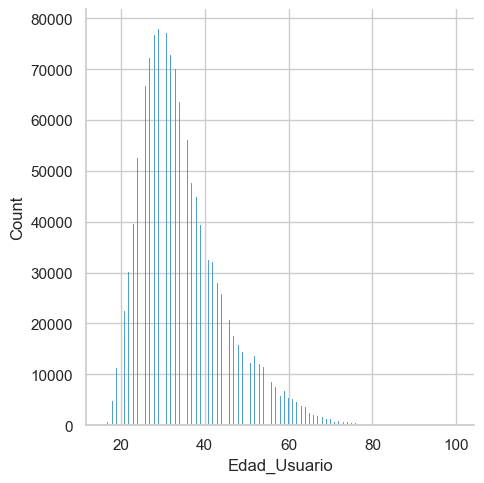

In [ ]:
sns.displot(
    data=df_clean, # ¿Qué conjunto de datos necesitamos aquí? ¿Necesitamos agregar?
    x="Edad_Usuario",
)

# ¿Cómo usan la ecobici?

## ¿Cuánto dura cada viaje?

In [ ]:
df_clean.assign(duracion_minutos=lambda x: x.duracion_viaje.dt.total_seconds() / 60).duracion_minutos.quantile([0.25, 0.5, 0.75,0.85,0.9,0.95,0.9999,1])

0.2500         7.083333
0.5000        11.833333
0.7500        19.850000
0.8500        25.766667
0.9000        30.183333
0.9500        36.783333
0.9999       565.437960
1.0000    257146.300000
Name: duracion_minutos, dtype: float64

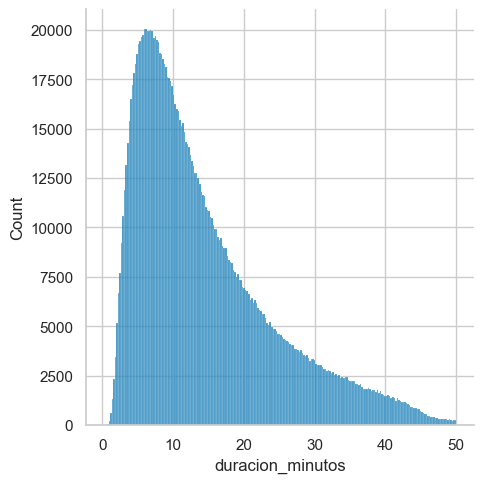

In [ ]:
sns.displot(
    data=df_clean.assign(duracion_minutos=lambda x: x.duracion_viaje.dt.total_seconds() / 60).query("duracion_minutos <= duracion_minutos.quantile(0.99)"), # ¿Qué conjunto de datos necesitamos aquí? ¿Necesitamos agregar?
    x='duracion_minutos',
)

¿Qué está pasando? ¿Cómo podemos resolverlo?

## ¿Cuántas veces usa la ecobici en promedio?

In [ ]:
# ¿Necesitamos agrupar para responder esta pregunta?
# Si es así, ¿por qué columna agrupamos y qué calculamos?

viajes_por_usuario = (
    df_clean
    .groupby("Bici")  # ¿Qué identifica a un usuario?
    .agg(
        num_viajes = ("Genero_Usuario", "size")  # ¿Qué columna contamos y con qué función?
    )
)

viajes_por_usuario.describe()

,num_viajes
count,7391.000000
mean,206.372886
std,57.242331
min,1.000000
25%,178.000000
50%,216.000000
75%,246.000000
max,337.000000


In [ ]:
viajes_por_usuario.quantile([0.25, 0.975])

NameError: name 'viajes_por_usuario' is not defined

# ¿Cuándo usan la ecobici?

Hasta ahora hemos analizado **quiénes** son los usuarios. Ahora queremos entender **cuándo** usan el sistema.

> **Reflexión previa**: Para cada pregunta que sigue, piensen antes de escribir código:
> - ¿Necesito agrupar los datos o puedo graficar directamente?
> - Si agrupo, ¿por qué columna(s)?
> - ¿Qué calculo dentro de cada grupo?

## ¿A qué hora del día se usa más la ecobici?

<Axes: xlabel='hora', ylabel='num_viajes'>

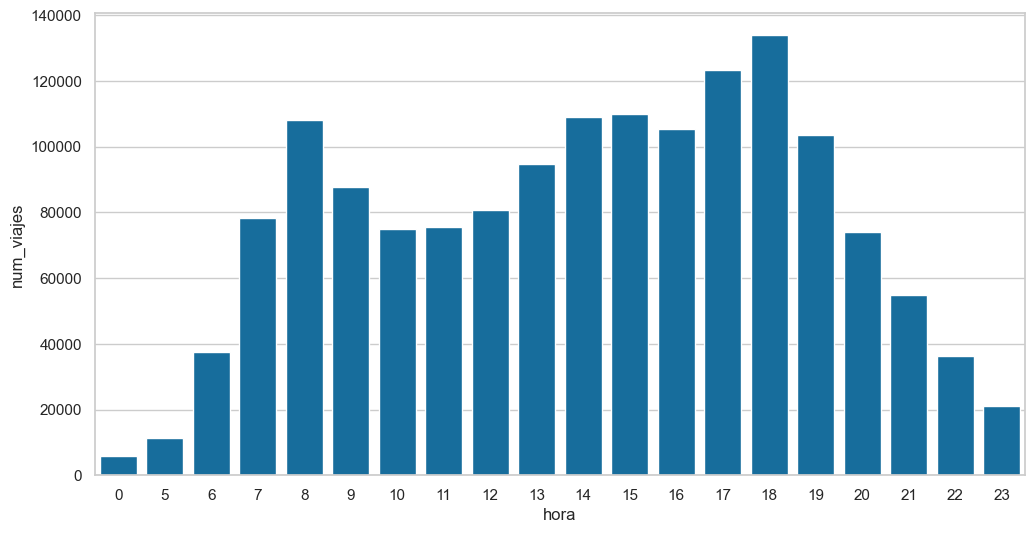

In [ ]:
# Primero extraemos la hora de inicio (ya tenemos la columna `inicio`)
df_hora = df_clean.assign(
    hora = lambda x: x.inicio.dt.hour  # Hint: dt.hour
)

# ¿Necesitamos agrupar? ¿O podemos pasar df_hora directamente a seaborn?
viajes_por_hora = (
    df_hora
    .groupby("hora")
    .agg(num_viajes = ("Genero_Usuario", "size"))
    .reset_index()
)

sns.barplot(
    data=viajes_por_hora,
    x="hora",
    y="num_viajes",
)

## ¿El patrón de uso por hora es igual entre semana y fin de semana?

Ahora la pregunta es más compleja: queremos ver la hora **y** el tipo de día al mismo tiempo.

> **Reflexión**: ¿Cómo cambia el `groupby` respecto al ejercicio anterior? ¿Por cuántas columnas agrupamos ahora?

<Axes: xlabel='hora', ylabel='num_viajes'>

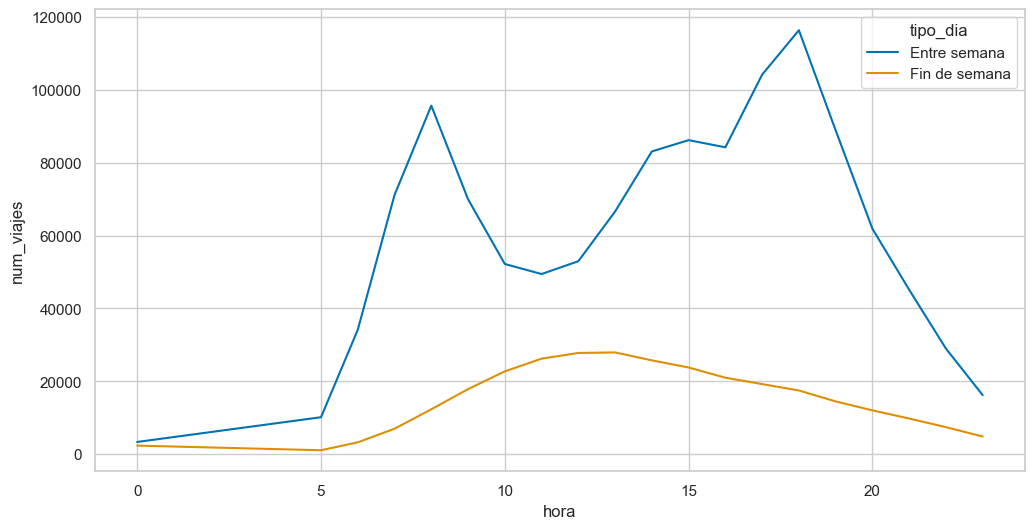

In [ ]:
FINES_DE_SEMANA = ['Saturday', 'Sunday']

df_tipo_dia = df_clean.assign(
    hora = lambda x: x.inicio.dt.hour,
    tipo_dia = lambda x: x.dia_semana.apply(
        lambda d: "Fin de semana" if d in FINES_DE_SEMANA else "Entre semana"  # 'Fin de semana' o 'Entre semana'
    )
)

viajes_hora_tipo = (
    df_tipo_dia
    .groupby(["hora", "tipo_dia"])  # ¿Por cuáles dos columnas agrupamos?
    .agg(num_viajes = ("Bici", "size"))
    .reset_index()
)

# ¿Cómo diferenciamos visualmente entre semana y fin de semana en la gráfica?
sns.lineplot(
    data=viajes_hora_tipo,
    x="hora",
    y="num_viajes",
    hue="tipo_dia",  # ¿Qué columna usamos para diferenciar los grupos?
)

# ¿Cómo difiere el uso entre grupos de usuarios?

Ahora combinamos las dimensiones de **quién** y **cómo** usa la ecobici.

> **Reflexión**: ¿Qué pasa cuando agrupamos por una variable categórica y queremos resumir una variable numérica? ¿Qué función de agregación tiene sentido usar?

## ¿La duración promedio del viaje difiere según el género del usuario?

In [ ]:
df_duracion = df_clean.assign(
    duracion_minutos = lambda x: x.duracion_viaje.dt.total_seconds() / 60
)

# Antes de graficar: ¿Qué valores de Genero_Usuario existen?
# ¿Necesitamos filtrar alguno?
print(df_duracion['Genero_Usuario'].value_counts())

duracion_por_genero = (
    df_duracion
    # Opcional: filtrar géneros con pocos registros o valores inesperados
    #.query("Genero_Usuario.isin(['F','M'])")
    .groupby('Genero_Usuario')
    .agg(
        duracion_promedio = ("duracion_minutos", "mean"),  # ¿Media, mediana? ¿Por qué?
        duracion_mediana  = ("duracion_minutos", "median"),
    )
    .reset_index()
)

duracion_por_genero

Genero_Usuario
M    1029960
F     418009
?      49853
O      27479
Name: count, dtype: int64


,Genero_Usuario,duracion_promedio,duracion_mediana
0,?,17.180245,12.983333
1,F,15.929397,12.250000
2,M,15.554328,11.600000
3,O,15.330871,11.900000


## ¿La hora de uso varía según el género?

> **Reflexión**: Esta pregunta requiere agrupar por **dos variables** simultáneamente. ¿Cómo afecta esto la forma del DataFrame resultante y cómo lo visualizamos?

<Axes: xlabel='hora', ylabel='num_viajes'>

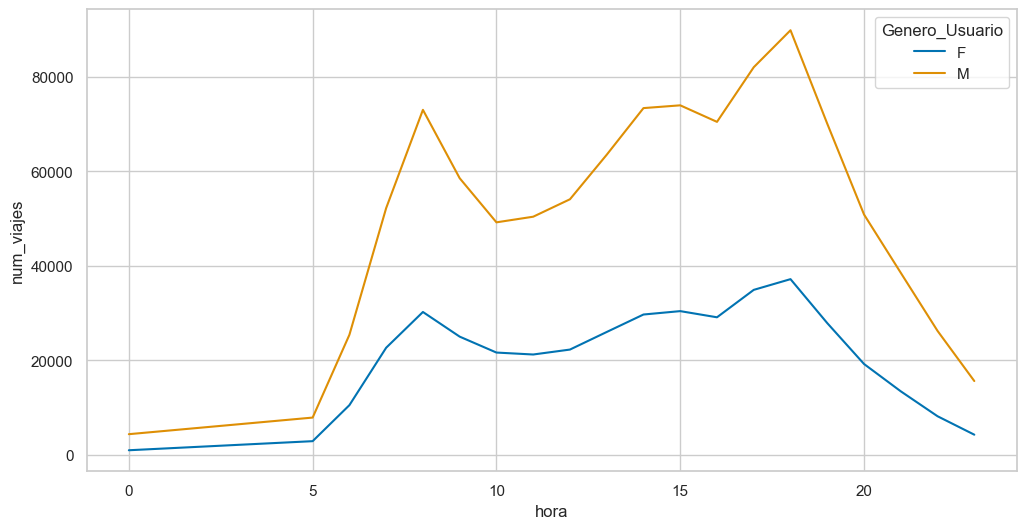

In [60]:
viajes_hora_genero = (
    df_clean
    .assign(hora = lambda x: x.inicio.dt.hour)
    .query("Genero_Usuario in ['M', 'F']")  # Filtramos valores válidos
    .groupby(["Genero_Usuario", "hora"])
    .agg(num_viajes = ("Bici", "count"))
    .reset_index()
)

sns.lineplot(
    data=viajes_hora_genero,
    x="hora",
    y="num_viajes",
    hue="Genero_Usuario",

)

# ¿Dónde usan la ecobici?

## ¿Cuáles son las estaciones con mayor demanda?

> **Reflexión**: Tenemos dos columnas de estación: `Ciclo_Estacion_Retiro` (origen) y `Ciclo_EstacionArribo` (destino). ¿Qué pregunta responde cada una? ¿Qué significa que una estación tenga muchos retiros pero pocos arribos?

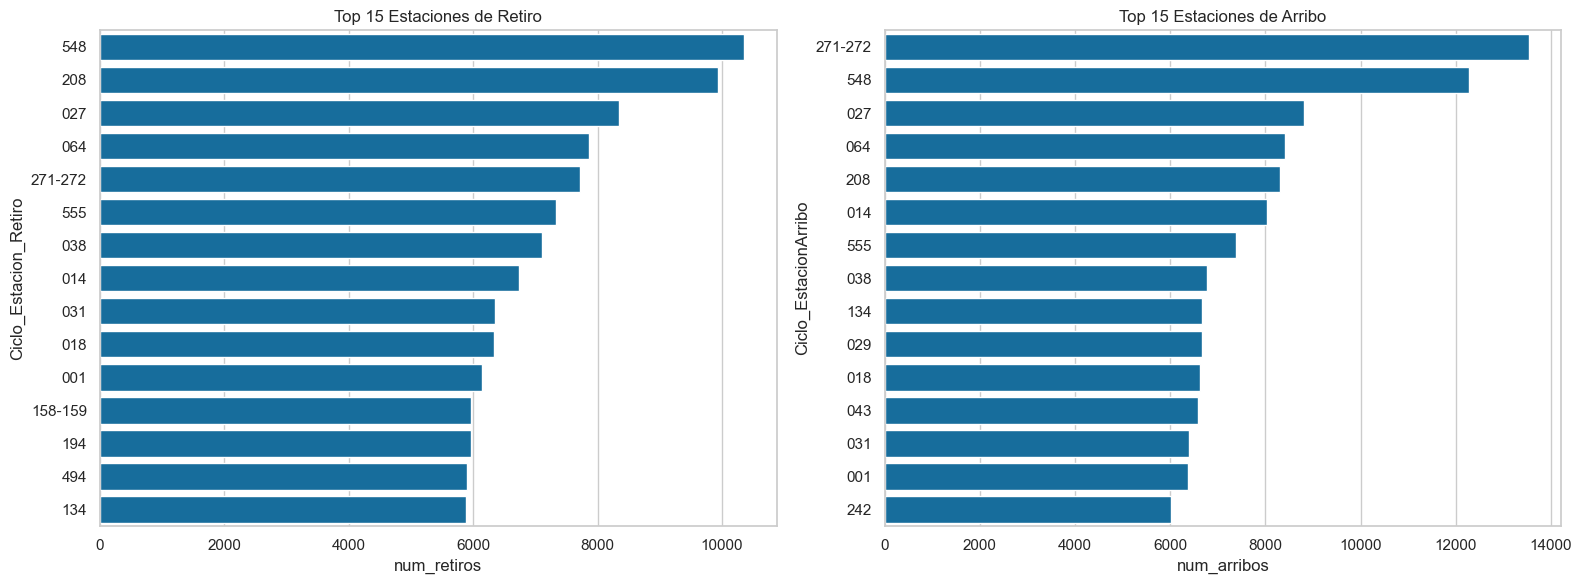

In [68]:
TOP_N = 15

# Estaciones con más viajes iniciados (retiros)
top_retiros = (
    df_clean
    .groupby("Ciclo_Estacion_Retiro")
    .agg(num_retiros = ("Genero_Usuario", "count"))
    .reset_index()
    .sort_values("num_retiros", ascending=False)  # ¿Ascendente o descendente?
    .head(TOP_N)
)

# Estaciones con más viajes terminados (arribos)
top_arribos = (
    df_clean
    .groupby("Ciclo_EstacionArribo")
    .agg(num_arribos = ("Genero_Usuario", "count"))
    .reset_index()
    .sort_values("num_arribos", ascending=False)
    .head(TOP_N)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_retiros, y="Ciclo_Estacion_Retiro", x="num_retiros", ax=axes[0])
axes[0].set_title("Top 15 Estaciones de Retiro")

sns.barplot(data=top_arribos, y="Ciclo_EstacionArribo", x="num_arribos", ax=axes[1])
axes[1].set_title("Top 15 Estaciones de Arribo")

plt.tight_layout()

## ¿Cuáles son los pares origen-destino más frecuentes?

> **Reflexión**: Ahora agrupamos por **dos columnas de categorías** al mismo tiempo. El resultado ya no es una lista de estaciones, sino una tabla de pares. ¿Cómo cambia la interpretación?

In [69]:
pares_od = (
    df_clean
    .groupby(["Ciclo_Estacion_Retiro", "Ciclo_EstacionArribo"])  # origen y destino
    .agg(num_viajes = ("Genero_Usuario", "count"))
    .reset_index()
    .sort_values("num_viajes", ascending=False)
    .head(20)
)

pares_od

,Ciclo_Estacion_Retiro,Ciclo_EstacionArribo,num_viajes
182955,621,618,864
153327,494,486,697
182280,618,621,646
153648,495,499,582
161055,539,548,497
151363,486,494,493
200411,710,710,486
64781,174,183,462
154552,499,495,453
76103,208,242,448


¿Hay viajes donde el origen y el destino son la **misma estación**? ¿Qué podrían significar? ¿Deberíamos incluirlos en nuestro análisis?

# ¿Dónde están las estaciones de EcoBici?

Contamos con un segundo dataset que tiene la **ubicación geográfica** de cada cicloestación. Para poder usarlo junto con los viajes, necesitamos **unir** ambas tablas.

> **Reflexión previa**: 
> - ¿Qué columna del dataset de viajes se relaciona con el dataset de estaciones?
> - ¿Necesitamos el mismo `groupby` de antes antes de hacer el join, o podemos unir directamente?

In [73]:
%pip install nbformat

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)

   ---------------------- ----------------- 4/7 [jsonschema-specifications]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------------- 7/7 [nbformat]

Note: you may need to restart the kernel to use updated packages.


In [74]:
import plotly.express as px

estaciones = pd.read_csv(
    "https://datos.cdmx.gob.mx/dataset/a1d7c132-fb1b-4e8c-bb74-4bb618563eb2/resource/5fbacfcc-f677-406c-9356-6ced541240fe/download/cicloestaciones_ecobici.csv",
    encoding="Latin1"
    )
estaciones.head()

,sistema,num_cicloe,calle_prin,calle_secu,colonia,alcaldia,latitud,longitud,sitio_de_e,estatus
0,Ecobici,423,Moras,Eje 8 Sur Jose Maria Rico,Acacias,Benito Juarez,19.367816,-99.175269,Arroyo,Instalada
1,Ecobici,437,Moras,Comunal,Acacias,Benito Juarez,19.364916,-99.175985,Arroyo,Instalada
2,Ecobici,438,Adolfo Prieto,Jose Maria Olloqui,Acacias,Benito Juarez,19.364730,-99.174447,Arroyo,Instalada
3,Ecobici,439,Amores,Avenida Coyoacan,Acacias,Benito Juarez,19.362037,-99.172683,Arroyo,Instalada
4,Ecobici,440,Martin Mendalde,M. Lopez Cotilla,Acacias,Benito Juarez,19.361699,-99.171387,Arroyo,Instalada


## Mapa base: ¿dónde está cada estación?

Antes de cruzar con los viajes, grafiquemos simplemente la ubicación de todas las estaciones.

In [77]:
px.scatter_map(
    data_frame=estaciones,
    lat="latitud",       # columna con latitud
    lon="longitud",       # columna con longitud
    hover_name="calle_prin", # ¿qué queremos ver al pasar el mouse?
    zoom=11,
    height=500,
)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': '<b>%{hovertext}</b><br><br>latitud=%{lat}<br>longitud=%{lon}<extra></extra>',
              'hovertext': array(['Moras', 'Moras', 'Adolfo Prieto', ..., nan, nan, nan],
                                 shape=(989,), dtype=object),
              'lat': {'bdata': ('D/J6MCleM0CCyY0ia10zQL7e/fFeXT' ... 'AAAPh/AAAAAAAA+H8AAAAAAAD4fw=='),
                      'dtype': 'f8'},
              'legendgroup': '',
              'lon': {'bdata': ('K8B3mzfLWMCK5ZZWQ8tYwKn4vyMqy1' ... 'AAAPh/AAAAAAAA+H8AAAAAAAD4fw=='),
                      'dtype': 'f8'},
              'marker': {'color': '#636efa'},
              'mode': 'markers',
              'name': '',
              'showlegend': False,
              'subplot': 'map',
              'type': 'scattermap'}],
    'layout': {'height': 500,
               'legend': {'tracegroupgap': 0},
               'map': {'center': {'lat': np.float64(19.408341546026588), 'lon': np.float64(-99.1675668078582)},
                       'domain': {'x': [0.0, 1.0], 'y': [0.0, 1.0]},
                       'zoom': 11},
               'mapbox': {'center': {'lat': np.float64(19.408341546026588), 'lon': np.float64(-99.1675668078582)},
                          'zoom': 11},
               'margin': {'t': 60},
               'template': '...'}
})

## ¿Cuáles estaciones tienen más retiros?

Ahora queremos que el **tamaño** y **color** de cada punto refleje cuántos viajes se iniciaron en esa estación.

Para lograrlo necesitamos:
1. Agregar los viajes por estación de retiro (ya lo hicimos antes)
2. **Unir** ese resultado con el dataset de estaciones (para obtener lat/lon)

> **Reflexión**: ¿Qué tipo de join necesitamos? ¿`inner`, `left`, `right`? ¿Qué pasa si una estación tiene viajes pero no aparece en el dataset de ubicaciones, o viceversa?

In [ ]:
retiros_por_estacion = (
    df_clean
    .groupby("Ciclo_Estacion_Retiro")                             # ¿Por qué columna agrupamos?
    .agg(num_retiros=("Genero_Usario","count"))
    .reset_index()
    .rename(columns={"Ciclo_Estacion_Retiro": 'num_cicloe'})      # Igualamos el nombre de la llave
)

# Unimos con las coordenadas
mapa_retiros = retiros_por_estacion.merge(
    estaciones[['num_cicloe', 'latitud', 'longitud', 'calle_prin', 'alcaldia']],
    #on="num_clicloe",   # ¿Cuál es la llave?
    #how=_____,  # ¿Qué tipo de join usamos?
)

mapa_retiros.head()

KeyError: "Label(s) ['Genero_Usario'] do not exist"

In [ ]:
px.scatter_map(
    data_frame=mapa_retiros,
    lat=_____,
    lon=_____,
    size=_____,           # ¿Qué columna determina el tamaño del punto?
    color=_____,          # ¿Y el color?
    hover_name=_____,
    hover_data={'alcaldia': True, 'num_retiros': True, 'latitud': False, 'longitud': False},
    color_continuous_scale='Reds',
    size_max=30,
    zoom=11,
    height=600,
    title='Estaciones de EcoBici: demanda de retiros',
)

## ¿Hay estaciones que "expulsan" más bicicletas de las que reciben?

Una estación con muchos **retiros** y pocos **arribos** pierde bicicletas durante el día (piensen en las estaciones cerca del metro por las mañanas). El **flujo neto** = arribos − retiros nos dice qué estaciones acumulan o pierden bicicletas.

> **Reflexión**: ¿Cómo construimos esta tabla? ¿Cuántos `groupby` necesitamos y cómo los combinamos?

In [52]:
retiros = (
    df_clean
    .groupby('Ciclo_Estacion_Retiro')
    .agg(num_retiros=('Bici', 'count'))
    .reset_index()
    .rename(columns={'Ciclo_Estacion_Retiro': 'num_cicloe'})
)

arribos = (
    df_clean
    .groupby('Ciclo_EstacionArribo')
    .agg(num_arribos=('Bici', 'count'))
    .reset_index()
    .rename(columns={"Ciclo_EstacionArribo": 'num_cicloe'})
)

# Unimos retiros y arribos en una sola tabla por estación
flujo = (
    retiros
    .merge(arribos)
    .assign(flujo_neto = lambda x: x.num_arribos - x.num_retiros) # arribos - retiros
    .merge(
        estaciones[['num_cicloe', 'latitud', 'longitud', 'calle_prin', 'alcaldia']],
        on='num_cicloe',
        how='inner',
    )
)

flujo.sort_values('flujo_neto').head(10)  # Estaciones que más pierden bicicletas

,num_cicloe,num_retiros,num_arribos,flujo_neto,latitud,longitud,calle_prin,alcaldia
203,208,9934,8300,-1634,19.434182,-99.189835,Hesiodo,Miguel Hidalgo
231,237-238,5726,4597,-1129,19.426744,-99.193986,Andres Bello,Miguel Hidalgo
206,211,3848,2951,-897,19.433607,-99.188528,Isaac Newton,Miguel Hidalgo
205,210,2342,1464,-878,19.434076,-99.194091,Eugenio Sue,Miguel Hidalgo
459,495,5141,4267,-874,19.445528,-99.166934,Amado Nervo,Miguel Hidalgo
675,711,2730,1859,-871,19.413668,-99.191953,Molino del Rey,Miguel Hidalgo
458,494,5893,5094,-799,19.444053,-99.167429,Tlaloc,Miguel Hidalgo
419,455,2686,1919,-767,19.426308,-99.203300,Pedregal,Miguel Hidalgo
639,675,3415,2658,-757,19.362553,-99.188953,Manuel Castro Padilla,Alvaro Obregon
674,710,3402,2653,-749,19.416842,-99.192520,Molino del Rey,Miguel Hidalgo


In [59]:
px.scatter_map(
    data_frame=flujo,
    lat='latitud',
    lon='longitud',
    color="flujo_neto",                              # flujo_neto: negativo = pierde, positivo = acumula
    #hover_name=_____,
    hover_data={'alcaldia': True, 'flujo_neto': True, 'latitud': False, 'longitud': False},
    color_continuous_scale='RdBu',             # Hint: 'RdBu' diferencia positivos y negativos
    #color_continuous_midpoint=_____,          # ¿Cuál debería ser el punto medio de la escala?
    size=flujo['flujo_neto'].abs(),           # El tamaño muestra la magnitud del desequilibrio
    size_max=25,
    zoom=11,
    height=600,
    title='Flujo neto de bicicletas por estación (arribos − retiros)',
)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([['Cuauhtemoc', 227, 19.4335895, -99.1678193],
                                   ['Cuauhtemoc', -116, 19.43062276, -99.17123066],
                                   ['Cuauhtemoc', -231, 19.43163, -99.158547],
                                   ...,
                                   ['Coyoacan', 421, 19.344271, -99.149973],
                                   ['Miguel Hidalgo', -749, 19.4168415, -99.1925204],
                                   ['Miguel Hidalgo', -871, 19.4136683, -99.1919528]],
                                  shape=(676, 4), dtype=object),
              'hovertemplate': ('size=%{marker.size}<br>alcaldi' ... '%{marker.color}<extra></extra>'),
              'lat': {'bdata': ('lWOyuP9uM0D+HA9LPW4zQPT4vU1/bj' ... '0kIlgzQJcd4h+2ajNAVeRrKuZpM0A='),
                      'dtype': 'f8'},
              'legendgroup': '',
              'lon': {'bdata': ('z0gpjb3KWMBxMXFx9cpYwED4UKIlyl' ... 'oomclYwAZ0FUFSzFjACphl9EjMWMA='),
                      'dtype': 'f8'},
              'marker': {'color': {'bdata': ('4wCM/xn/qwEPAaL/5P7T/+z/Xf+OAA' ... 'oAAAAjAI8AqwAeAN3/VAGlARP9mfw='),
                                   'dtype': 'i2'},
                         'coloraxis': 'coloraxis',
                         'size': {'bdata': ('4wB0AOcAqwEPAV4AHAEtABQAowCOAA' ... 'oAAAAjAI8AqwAeACMAVAGlAe0CZwM='),
                                  'dtype': 'i2'},
                         'sizemode': 'area',
                         'sizeref': 9.32},
              'mode': 'markers',
              'name': '',
              'showlegend': False,
              'subplot': 'map',
              'type': 'scattermap'}],
    'layout': {'coloraxis': {'colorbar': {'title': {'text': 'flujo_neto'}},
                             'colorscale': [[0.0, 'rgb(103,0,31)'], [0.1,
                                            'rgb(178,24,43)'], [0.2,
                                            'rgb(214,96,77)'], [0.3,
                                            'rgb(244,165,130)'], [0.4,
                                            'rgb(253,219,199)'], [0.5,
                                            'rgb(247,247,247)'], [0.6,
                                            'rgb(209,229,240)'], [0.7,
                                            'rgb(146,197,222)'], [0.8,
                                            'rgb(67,147,195)'], [0.9,
                                            'rgb(33,102,172)'], [1.0,
                                            'rgb(5,48,97)']]},
               'height': 600,
               'legend': {'itemsizing': 'constant', 'tracegroupgap': 0},
               'map': {'center': {'lat': np.float64(19.408396848609467), 'lon': np.float64(-99.16757964928995)},
                       'domain': {'x': [0.0, 1.0], 'y': [0.0, 1.0]},
                       'zoom': 11},
               'mapbox': {'center': {'lat': np.float64(19.408396848609467), 'lon': np.float64(-99.16757964928995)},
                          'zoom': 11},
               'template': '...',
               'title': {'text': 'Flujo neto de bicicletas por estación (arribos − retiros)'}}
})

## ¿Podemos ver los flujos más frecuentes como líneas en el mapa?

Para dibujar una línea entre dos puntos en `plotly`, necesitamos que cada línea esté representada por **dos filas consecutivas** en el DataFrame (origen y destino), identificadas por un mismo grupo.

> **Reflexión**: Hasta ahora cada fila representaba una estación. Ahora necesitamos que cada par O-D ocupe **dos filas**. ¿Cómo transformamos los datos para llegar a esa estructura?

In [ ]:
TOP_N = 30

# Paso 1: obtener los pares O-D más frecuentes con un ID único por par
pares_top = (
    df_clean
    .groupby([_____, _____])
    .agg(num_viajes=(_____, _____))
    .reset_index()
    .sort_values('num_viajes', ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
    .assign(par_id=lambda x: x.index)  # ID único para cada par
)

coords = estaciones[['num_cicloe', 'latitud', 'longitud', 'calle_prin']]

# Paso 2: unir coordenadas del ORIGEN
origen = (
    pares_top
    .merge(
        coords.rename(columns={'num_cicloe': _____, 'latitud': 'lat', 'longitud': 'lon', 'calle_prin': 'nombre'}),
        on=_____,
        how='left',
    )
)

# Paso 3: unir coordenadas del DESTINO
destino = (
    pares_top
    .merge(
        coords.rename(columns={'num_cicloe': _____, 'latitud': 'lat', 'longitud': 'lon', 'calle_prin': 'nombre'}),
        on=_____,
        how='left',
    )
)

# Paso 4: concatenar ambos — cada par queda en dos filas consecutivas
lineas = (
    pd.concat([origen, destino])
    .sort_values(_____)  # ¿Por qué columna ordenamos para que plotly conecte los puntos correctamente?
)

lineas.head(6)

In [ ]:
px.line_map(
    data_frame=lineas,
    lat=_____,
    lon=_____,
    line_group=_____,      # ¿Qué columna agrupa los dos puntos de cada línea?
    color=_____,           # ¿Qué columna usamos para indicar la frecuencia del par?
    hover_name=_____,
    zoom=11,
    height=600,
    title=f'Top {TOP_N} pares origen-destino más frecuentes',
)